In [16]:
from pathlib import Path
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


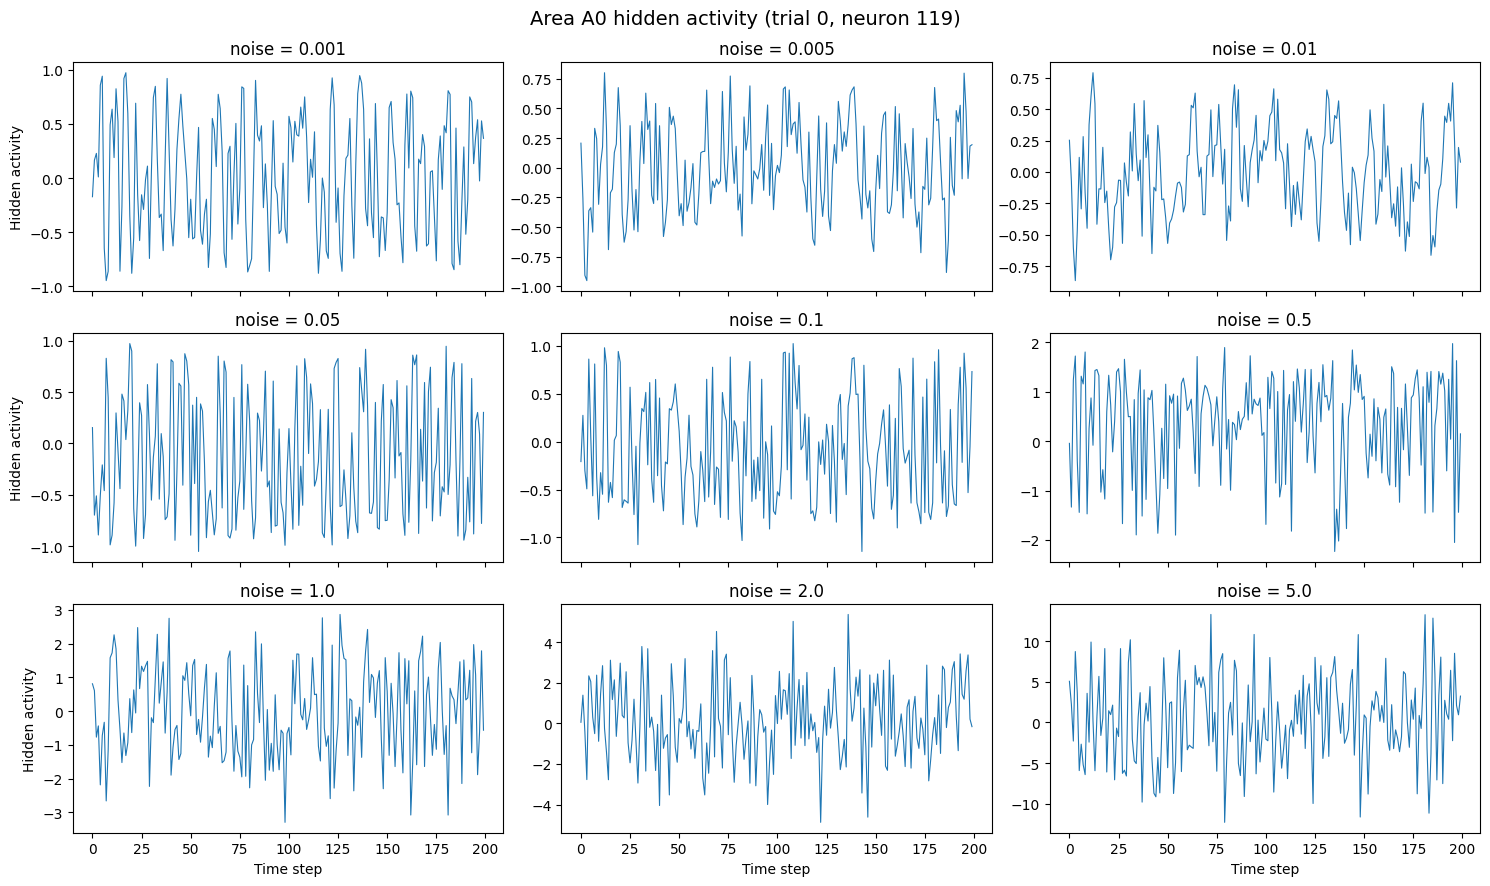

In [17]:
# Plot hidden activity of a neuron in area A0 for varying noise levels

trial_idx = 0
neuron_idx = 119
area_key = "area-A0"

noise_runs_dir = Path("..") / "runs" / "noise_runs"
run_dirs = sorted(
    [p for p in noise_runs_dir.iterdir() if p.is_dir()],
    key=lambda p: float(re.search(r"_n([\d.]+)_", p.name).group(1)),
)

ncols = 3
nrows = int(np.ceil(len(run_dirs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=True)
axes = np.atleast_1d(axes).flatten()

for i, (ax, run_dir) in enumerate(zip(axes, run_dirs)):
    with h5py.File(run_dir / "data.h5", "r") as h:
        activity = h["0"][area_key][trial_idx, :, neuron_idx]

    row, col = divmod(i, ncols)
    noise = float(re.search(r"_n([\d.]+)_", run_dir.name).group(1))
    ax.plot(activity, color="C0", linewidth=0.8)
    ax.set_title(f"noise = {noise}")
    if col == 0:
        ax.set_ylabel("Hidden activity")
    if row == nrows - 1:
        ax.set_xlabel("Time step")
    # ax.grid(True, alpha=0.3)

# for ax in axes[len(run_dirs) :]:
#     ax.axis("off")

fig.suptitle(f"Area A0 hidden activity (trial {trial_idx}, neuron {neuron_idx})", fontsize=14)
fig.tight_layout()
fig.savefig("../figures/hidden_activity_by_noise.png", dpi=300)
plt.show()

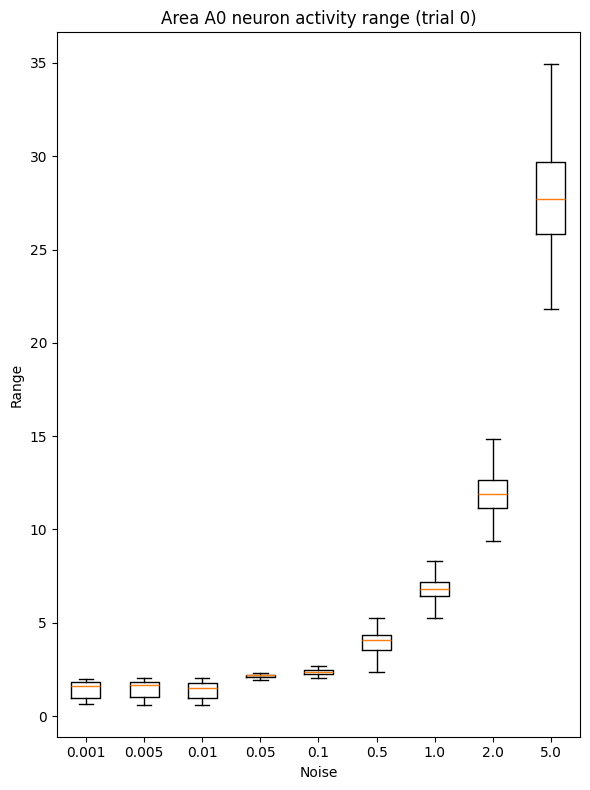

In [18]:
# Box plot of per-neuron activity range for trial 0

ranges_by_noise = []
noise_levels = []

for run_dir in run_dirs:
    with h5py.File(run_dir / "data.h5", "r") as h:
        trial_activity = h["0"][area_key][trial_idx]

    neuron_ranges = trial_activity.max(axis=0) - trial_activity.min(axis=0)
    ranges_by_noise.append(neuron_ranges)
    noise_levels.append(float(re.search(r"_n([\d.]+)_", run_dir.name).group(1)))

fig, ax = plt.subplots(figsize=(6, 8))
ax.boxplot(ranges_by_noise, tick_labels=[str(n) for n in noise_levels], showfliers=False)
ax.set_xlabel("Noise")
ax.set_ylabel("Range")
ax.set_title(f"Area A0 neuron activity range (trial {trial_idx})")
fig.tight_layout()
plt.show()

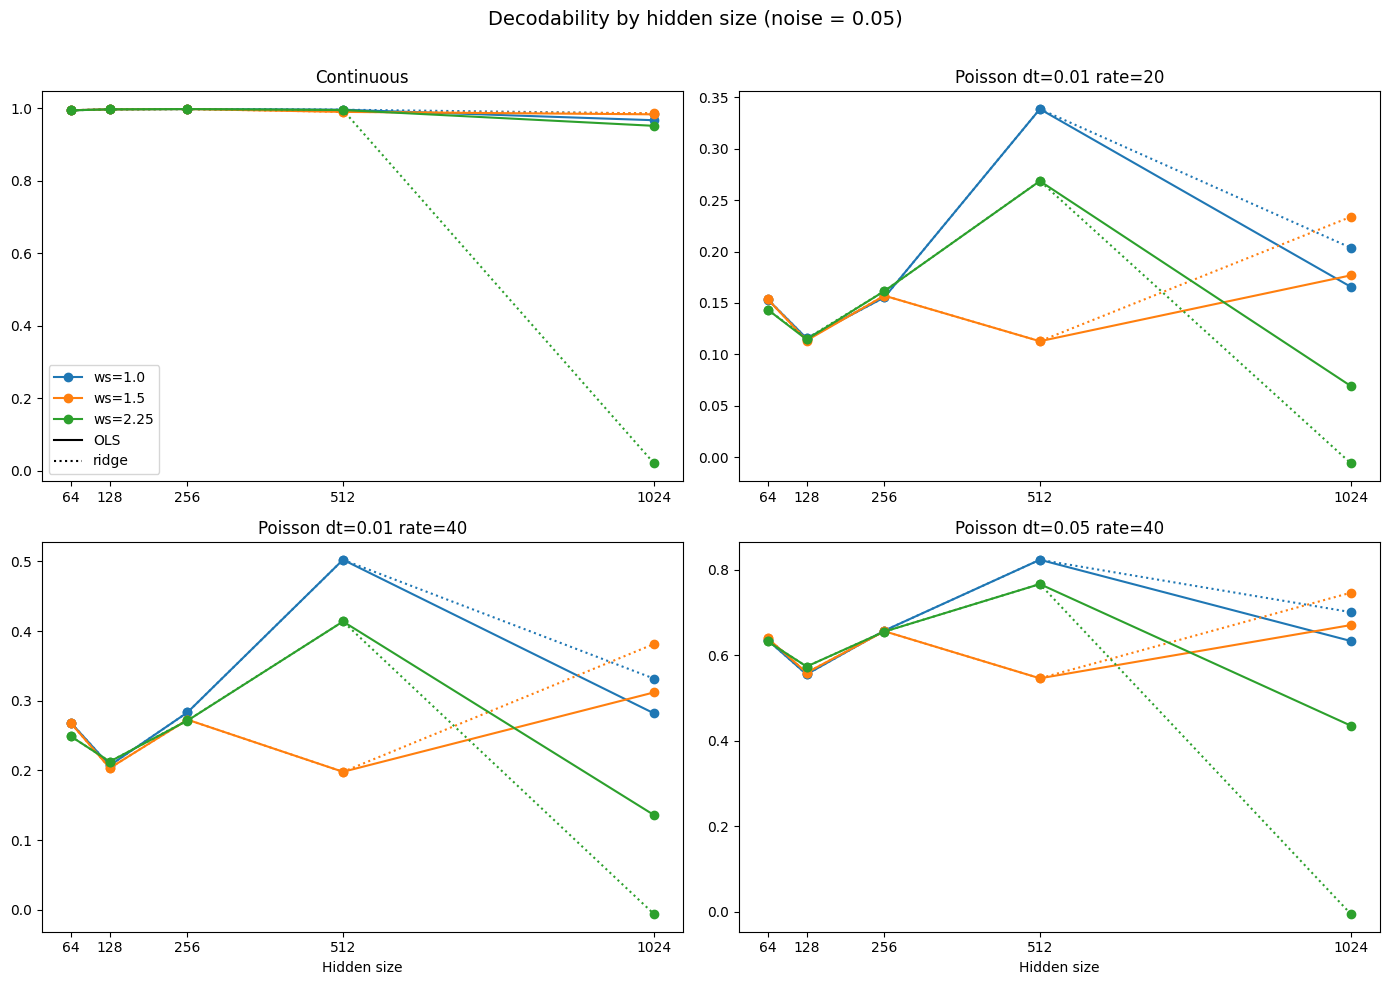

In [19]:
# Decodability by hidden size and input weight scales

hs_ws_df = pd.read_csv(Path("..") / "runs" / "hs_ws_runs" / "decodability_results.csv")
ridge_df = pd.read_csv(
    Path("..") / "runs" / "hs_ws_runs" / "ridge_decodability_results.csv",
    header=None,
    names=[
        "run_name", "hidden_size", "noise", "ws", "memory", "seed", "swept",
        "score_continuous", "score_poisson_dt0.01_rate20",
        "score_poisson_dt0.01_rate40", "score_poisson_dt0.05_rate40",
    ],
)

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

from matplotlib.lines import Line2D

ws_values = sorted(hs_ws_df["ws"].unique())
hidden_sizes = sorted(hs_ws_df["hidden_size"].unique())
ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, metric_columns.items()):
    for ws in ws_values:
        color = ws_colors[ws]
        subset = hs_ws_df[hs_ws_df["ws"] == ws].sort_values("hidden_size")
        ridge_subset = ridge_df[ridge_df["ws"] == ws].sort_values("hidden_size")
        ax.plot(
            subset["hidden_size"],
            subset[metric],
            marker="o",
            linestyle="-",
            color=color,
            label=f"ws={ws}",
        )
        ax.plot(
            ridge_subset["hidden_size"],
            ridge_subset[metric],
            marker="o",
            linestyle=":",
            color=color,
            label="_nolegend_",
        )
        if ax == axes[2] or ax == axes[3]:
            ax.set_xlabel("Hidden size")

    ax.set_title(label)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels([str(h) for h in hidden_sizes])

ws_handles, ws_labels = axes[0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="ols"),
    Line2D([0], [0], color="k", linestyle=":", label="ridge"),
]
axes[0].legend(handles=ws_handles + style_handles, labels=ws_labels + ["OLS", "ridge"])
fig.suptitle("Decodability by hidden size (noise = 0.05)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

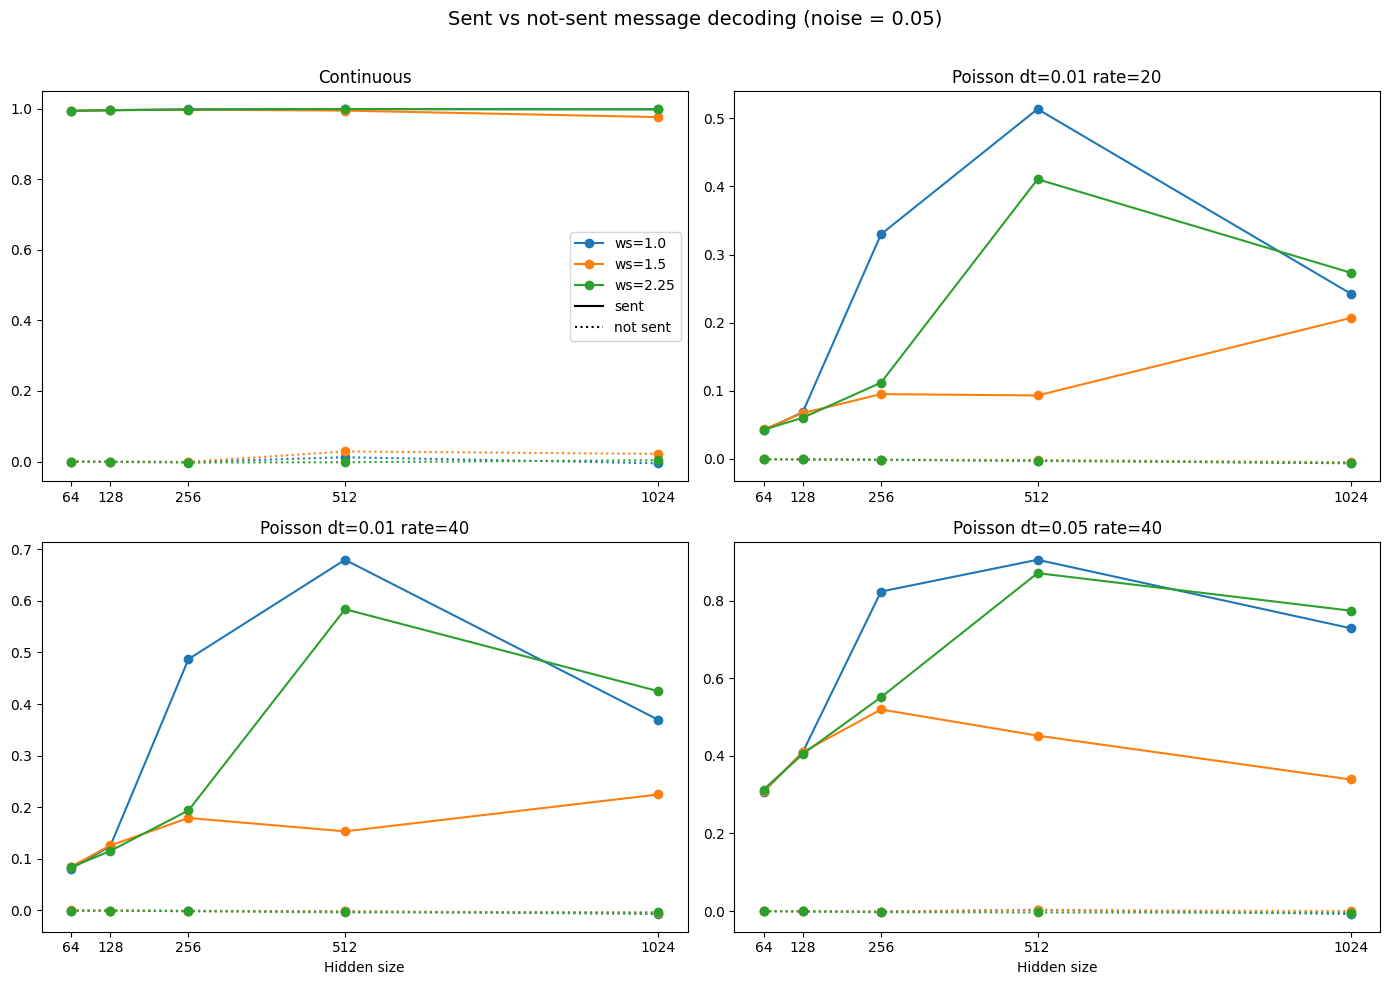

In [20]:
# Message comparison: sent vs not-sent R² by hidden size and weight scale

msg_df = pd.read_csv(
    Path("..") / "runs" / "hs_ws_runs" / "message_comparison_results_hs_ws.csv"
)
msg_df["representation"] = msg_df["representation"].str.strip()

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

from matplotlib.lines import Line2D

ws_values = sorted(msg_df["ws"].unique())
hidden_sizes = sorted(msg_df["hidden_size"].unique())
ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    rep_df = msg_df[msg_df["representation"] == rep]
    for ws in ws_values:
        color = ws_colors[ws]
        subset = rep_df[rep_df["ws"] == ws].sort_values("hidden_size")
        ax.plot(
            subset["hidden_size"],
            subset["r2_sent"],
            marker="o",
            linestyle="-",
            color=color,
            label=f"ws={ws}",
        )
        ax.plot(
            subset["hidden_size"],
            subset["r2_notsent"],
            marker="o",
            linestyle=":",
            color=color,
            label="_nolegend_",
        )
        if ax == axes[2] or ax == axes[3]:
            ax.set_xlabel("Hidden size")

    ax.set_title(label)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels([str(h) for h in hidden_sizes])

ws_handles, ws_labels = axes[0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="sent"),
    Line2D([0], [0], color="k", linestyle=":", label="not sent"),
]
axes[0].legend(handles=ws_handles + style_handles, labels=ws_labels + ["sent", "not sent"])
fig.suptitle("Sent vs not-sent message decoding (noise = 0.05)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

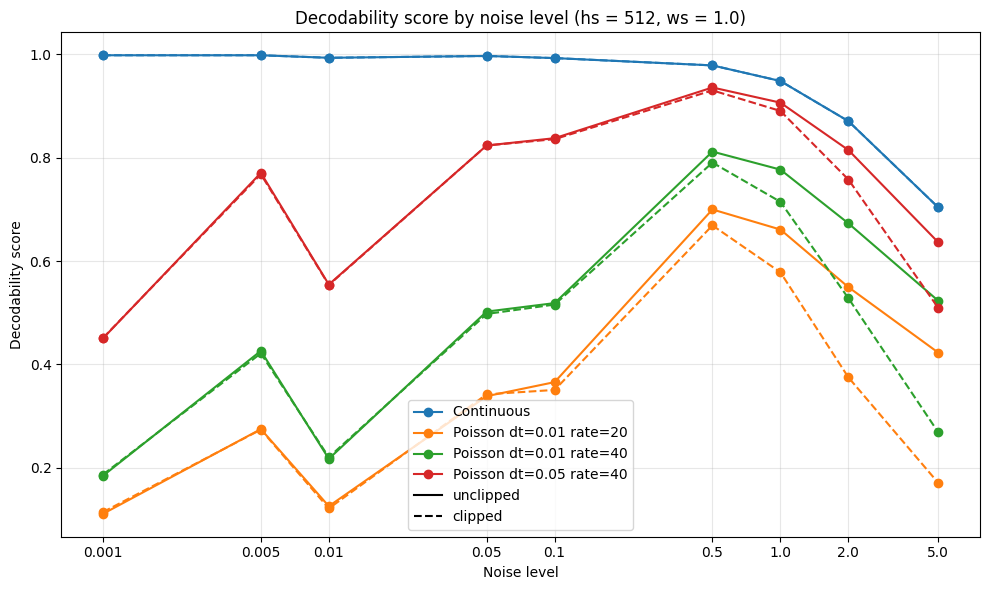

In [21]:
# Decodability by noise level

noise_df = pd.read_csv(Path("..") / "runs" / "noise_runs" / "decodability_results.csv")
clipped_df = pd.read_csv(Path("..") / "runs" / "noise_runs" / "clipped_decodability_results.csv")

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

noise_levels = sorted(noise_df["noise"].unique())
subset = noise_df.sort_values("noise")
clipped_subset = clipped_df.sort_values("noise")

fig, ax = plt.subplots(figsize=(10, 6))

for i, (metric, label) in enumerate(metric_columns.items()):
    color = f"C{i}"
    ax.plot(
        subset["noise"],
        subset[metric],
        marker="o",
        linestyle="-",
        color=color,
        label=label,
    )
    ax.plot(
        clipped_subset["noise"],
        clipped_subset[metric],
        marker="o",
        linestyle="--",
        color=color,
        label="_nolegend_",
    )

style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="unclipped"),
    Line2D([0], [0], color="k", linestyle="--", label="clipped"),
]
metric_handles, metric_labels = ax.get_legend_handles_labels()
ax.legend(
    handles=metric_handles + style_handles,
    labels=metric_labels + ["unclipped", "clipped"],
)

ax.set_xscale("log")
ax.xaxis.set_major_locator(FixedLocator(noise_levels))
ax.xaxis.set_minor_locator(NullLocator())
ax.set_xlabel("Noise level")
ax.set_ylabel("Decodability score")
ax.set_title("Decodability score by noise level (hs = 512, ws = 1.0)")
ax.set_xticklabels([str(n) for n in noise_levels])
ax.grid(True, which="major", alpha=0.3)
fig.tight_layout()
plt.show()

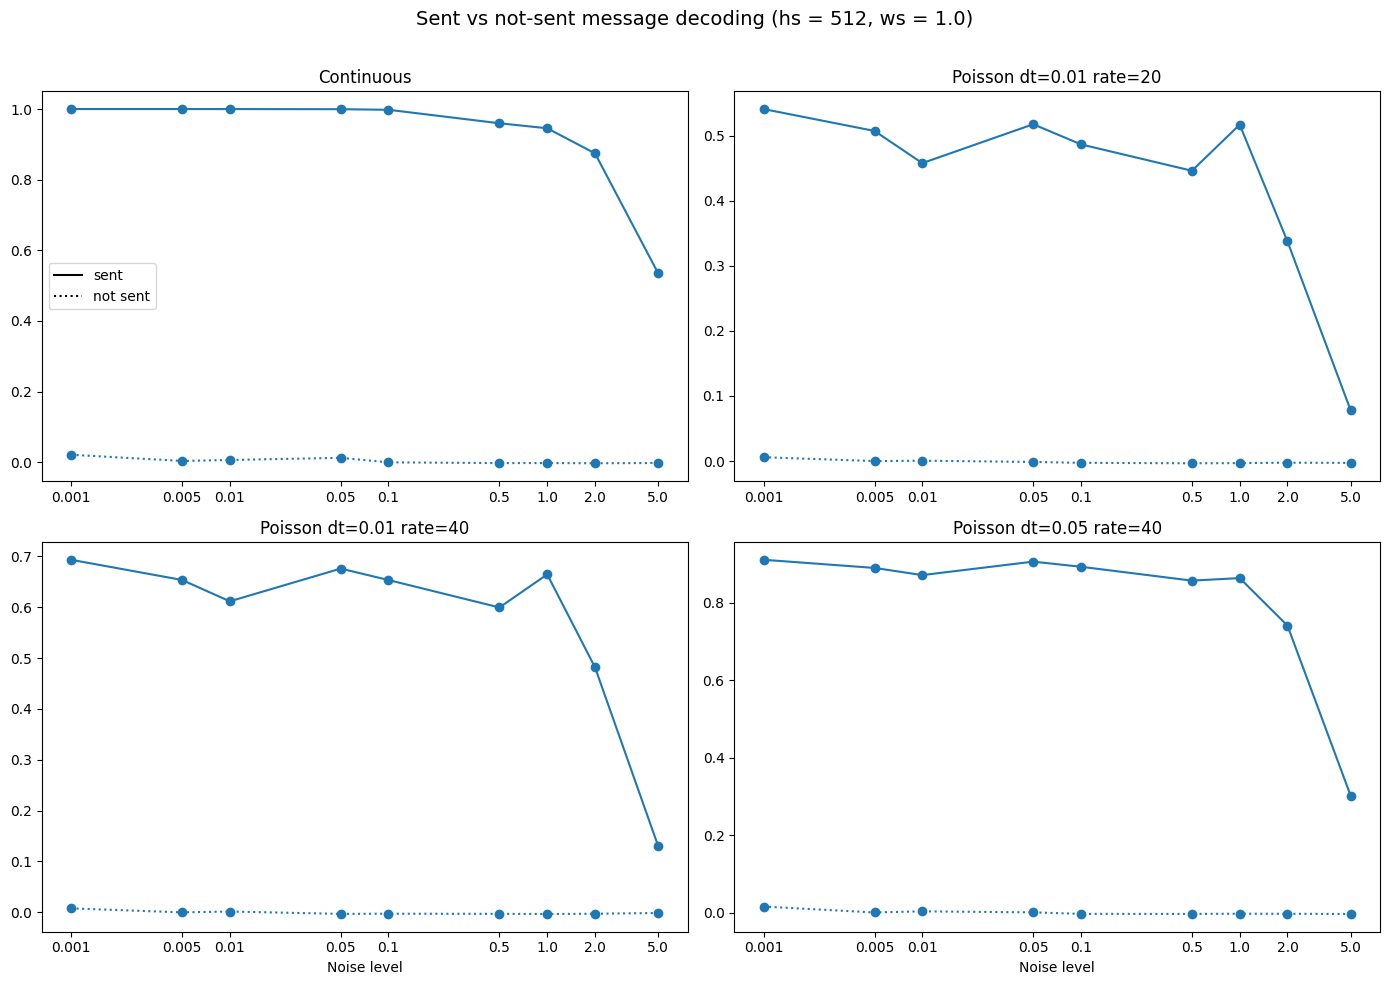

In [22]:
# Message comparison: sent vs not-sent R² by noise level

msg_noise_df = pd.read_csv(
    Path("..") / "runs" / "noise_runs" / "message_comparison_results_noise.csv"
)
msg_noise_df["representation"] = msg_noise_df["representation"].str.strip()

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

noise_levels = sorted(msg_noise_df["noise"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    subset = msg_noise_df[msg_noise_df["representation"] == rep].sort_values("noise")
    ax.plot(
        subset["noise"],
        subset["r2_sent"],
        marker="o",
        linestyle="-",
        color="C0",
    )
    ax.plot(
        subset["noise"],
        subset["r2_notsent"],
        marker="o",
        linestyle=":",
        color="C0",
    )

    ax.set_title(label)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    if ax == axes[2] or ax == axes[3]:
        ax.set_xlabel("Noise level")

style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="sent"),
    Line2D([0], [0], color="k", linestyle=":", label="not sent"),
]
axes[0].legend(handles=style_handles)
fig.suptitle("Sent vs not-sent message decoding (hs = 512, ws = 1.0)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

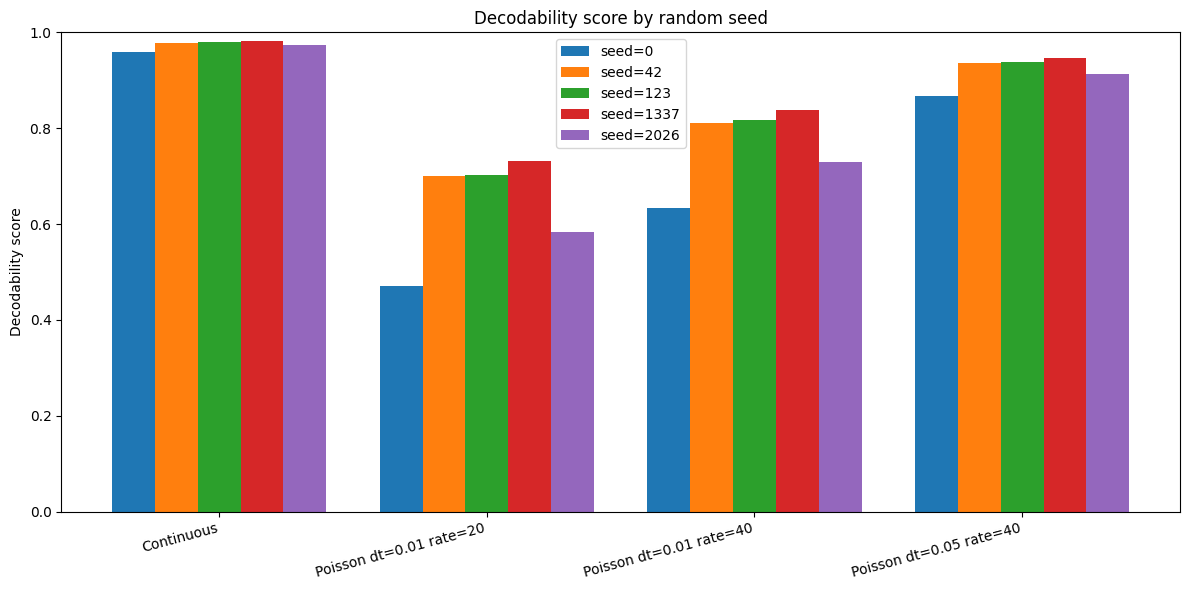

In [23]:
# Decodability by random seed

seed_df = pd.read_csv(Path("..") / "runs" / "seed_runs" / "decodability_results.csv")

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

seeds = sorted(seed_df["seed"].unique())
metrics = list(metric_columns.keys())
labels = list(metric_columns.values())

x = np.arange(len(metrics))
width = 0.8 / len(seeds)

fig, ax = plt.subplots(figsize=(12, 6))
for i, seed in enumerate(seeds):
    row = seed_df[seed_df["seed"] == seed].iloc[0]
    ax.bar(
        x + (i - (len(seeds) - 1) / 2) * width,
        [row[m] for m in metrics],
        width,
        label=f"seed={seed}",
        color=f"C{i}",
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Decodability score")
ax.set_title("Decodability score by random seed")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
plt.show()

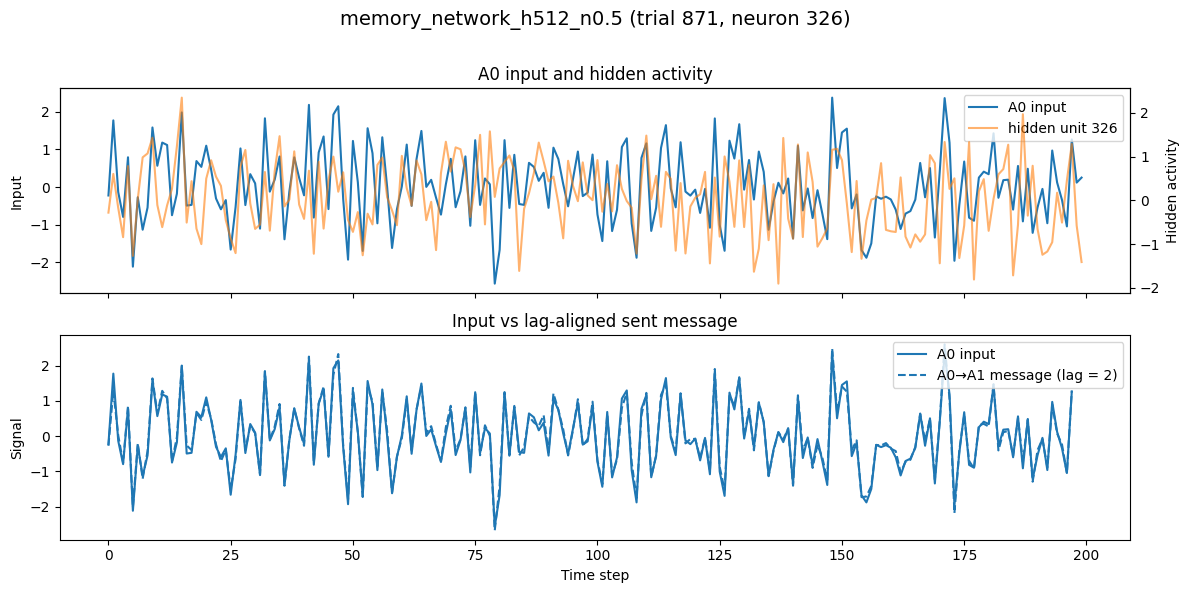

In [24]:
# A0 input vs time-lagged message sent from A0 (noise = 0.5 run)

import yaml

run_dir = Path("..") / "runs" / "noise_runs" / "memory_network_h512_n0.5_id2606221443"
with (run_dir / "hparams.yaml").open() as f:
    lag = int(yaml.safe_load(f)["lag"])

A0_INPUT_CH = 0
A0_TO_A1_MSG_CH = 2  # message-mesgs channel for A0 -> A1

with h5py.File(run_dir / "data.h5", "r") as h:
    g = h["0"]
    truth_inp = g["truth-inp"][:]
    mesgs = g["message-mesgs"][:]
    hidden_a0 = g["area-A0"][:]

rng = np.random.default_rng(0)
trial_idx = int(rng.integers(truth_inp.shape[0]))
neuron_idx = int(rng.integers(hidden_a0.shape[-1]))

inp = truth_inp[trial_idx, :, A0_INPUT_CH]
sent_msg = mesgs[trial_idx, :, A0_TO_A1_MSG_CH]
hidden = hidden_a0[trial_idx, :, neuron_idx]
time = np.arange(inp.shape[0])
align_time = time[:-lag]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(time, inp, color="C0", label="A0 input")
ax.set_ylabel("Input")
ax2 = ax.twinx()
ax2.plot(time, hidden, color="C1", alpha=0.6, label=f"hidden unit {neuron_idx}")
ax2.set_ylabel("Hidden activity")
ax.set_title("A0 input and hidden activity")
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [line.get_label() for line in lines], loc="upper right")

axes[1].plot(align_time, inp[:-lag], color="C0", label="A0 input")
axes[1].plot(
    align_time,
    sent_msg[lag:],
    color="C0",
    linestyle="--",
    label=f"A0→A1 message (lag = {lag})",
)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Signal")
axes[1].set_title("Input vs lag-aligned sent message")
axes[1].legend(loc="upper right")

fig.suptitle(
    f"memory_network_h512_n0.5 (trial {trial_idx}, neuron {neuron_idx})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [25]:
# --- Training verification helpers ---

import yaml
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def load_hparams(run_dir):
    with (run_dir / "hparams.yaml").open() as f:
        return yaml.safe_load(f)


def rank_idx(ranks, area):
    start = int(ranks[:area].sum())
    end = int(ranks[: area + 1].sum())
    return list(range(start, end))


def build_inp_extended(inp, connectome, ranks):
    parts = []
    n_areas = connectome.shape[0]
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                parts.append(inp[..., rank_idx(ranks, ib)])
    return np.concatenate(parts, axis=-1)


def build_inp_hist(inp, connectome, ranks, memory):
    parts = []
    n_areas = connectome.shape[0]
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                for ic in rank_idx(ranks, ib):
                    for ti in range(memory):
                        stop = None if memory - ti == 0 else -(memory - ti)
                        parts.append(inp[:, ti:stop, ic][..., None])
    return np.concatenate(parts, axis=-1)


def message_edge_labels(connectome, ranks):
    labels = []
    n_areas = connectome.shape[0]
    for ia in range(n_areas):
        for ib in range(n_areas):
            if connectome[ia, ib]:
                for ic in rank_idx(ranks, ib):
                    labels.append(f"A{ib}→A{ia}[{ic}]")
    return labels


def channelwise_r2(pred, target):
    return [
        float(r2_score(target[..., ch].reshape(-1), pred[..., ch].reshape(-1)))
        for ch in range(pred.shape[-1])
    ]


def mean_channelwise_r2(pred, target):
    return float(np.mean(channelwise_r2(pred, target)))


def audit_training_objectives(run_dir):
    hps = load_hparams(run_dir)
    connectome = np.array(hps["connectome"])
    ranks = np.array(hps["ranks"])
    lag = int(hps["lag"])
    memory = int(hps["memory"])

    with h5py.File(run_dir / "data.h5", "r") as h:
        g = h["0"]
        truth_inp = g["truth-inp"][:]
        mesgs = g["message-mesgs"][:]
        latents = g["message-latents"][:]
        hidden = {k.split("-", 1)[1]: g[k][:] for k in g.keys() if k.startswith("area-")}

    inp_ext = build_inp_extended(truth_inp, connectome, ranks)
    inp_hist = build_inp_hist(truth_inp, connectome, ranks, memory)

    mesg_pred = mesgs[:, lag:]
    mesg_tgt = inp_ext[:, :-lag]
    lat_pred = latents[:, memory + lag * 2 :]
    lat_tgt = inp_hist[:, :-lag * 2]

    return {
        "run_name": run_dir.name,
        "mesg_r2_mean": mean_channelwise_r2(mesg_pred, mesg_tgt),
        "latent_r2_mean": mean_channelwise_r2(lat_pred, lat_tgt),
        "mesg_r2_channels": channelwise_r2(mesg_pred, mesg_tgt),
        "latent_r2_channels": channelwise_r2(lat_pred, lat_tgt),
        "mesg_labels": message_edge_labels(connectome, ranks),
        "lag": lag,
        "memory": memory,
        "connectome": connectome,
        "ranks": ranks,
        "truth_inp": truth_inp,
        "mesgs": mesgs,
        "latents": latents,
        "hidden": hidden,
    }


def ridge_decode_r2(X, y, test_size=0.2, random_state=0):
    n_trials = X.shape[0]
    train_idx, test_idx = train_test_split(
        np.arange(n_trials), test_size=test_size, random_state=random_state, shuffle=True
    )
    x_train = X[train_idx].reshape(-1, X.shape[-1])
    y_train = y[train_idx].reshape(-1, y.shape[-1])
    x_test = X[test_idx].reshape(-1, X.shape[-1])
    y_test = y[test_idx].reshape(-1, y.shape[-1])
    reg = Ridge(alpha=1.0)
    reg.fit(x_train, y_train)
    return float(r2_score(y_test, reg.predict(x_test), multioutput="uniform_average"))


def load_tb_scalars(run_dir, tag):
    event_files = sorted(run_dir.glob("events.out.tfevents*"))
    if not event_files:
        return pd.DataFrame()
    ea = EventAccumulator(str(event_files[0]), size_guidance={"scalars": 0})
    ea.Reload()
    scalars = ea.Scalars(tag)
    if not scalars:
        return pd.DataFrame()
    return pd.DataFrame({"epoch": [s.step for s in scalars], "value": [s.value for s in scalars]})

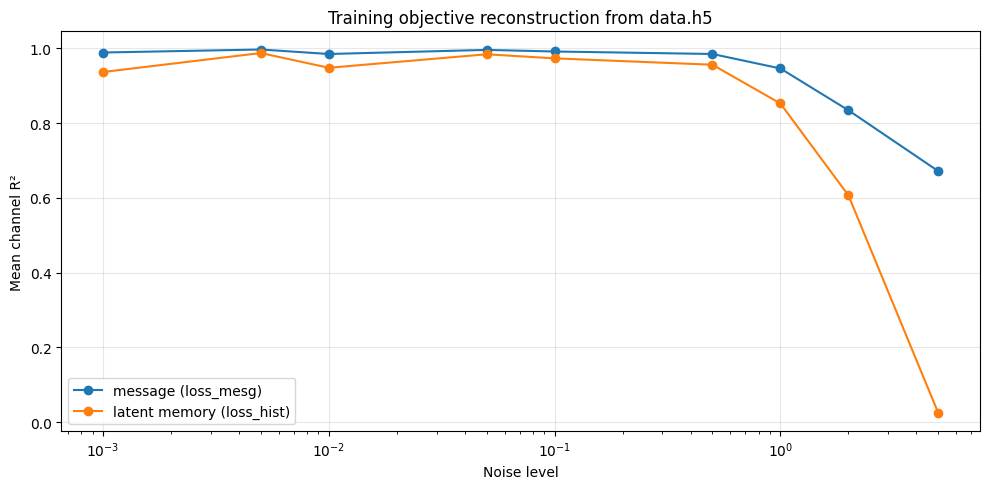

,noise,mesg_r2_mean,latent_r2_mean
0,0.001,0.988819,0.936708
1,0.005,0.996876,0.987435
2,0.010,0.984881,0.947972
3,0.050,0.995825,0.984119
4,0.100,0.991554,0.973165
5,0.500,0.984883,0.956156
6,1.000,0.946126,0.852446
7,2.000,0.834338,0.606704
8,5.000,0.671520,0.024567


In [26]:
# Offline training-objective reconstruction across noise runs

noise_runs_dir = Path("..") / "runs" / "noise_runs"
noise_run_dirs = sorted(
    [p for p in noise_runs_dir.iterdir() if p.is_dir()],
    key=lambda p: float(re.search(r"_n([\d.]+)_", p.name).group(1)),
)
n05_run = next(
    p for p in noise_run_dirs
    if float(re.search(r"_n([\d.]+)_", p.name).group(1)) == 0.5
)

audit_rows = []
for run_dir in noise_run_dirs:
    row = audit_training_objectives(run_dir)
    noise = float(re.search(r"_n([\d.]+)_", run_dir.name).group(1))
    audit_rows.append(
        {
            "noise": noise,
            "mesg_r2_mean": row["mesg_r2_mean"],
            "latent_r2_mean": row["latent_r2_mean"],
        }
    )

audit_df = pd.DataFrame(audit_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(audit_df["noise"], audit_df["mesg_r2_mean"], marker="o", label="message (loss_mesg)")
ax.plot(audit_df["noise"], audit_df["latent_r2_mean"], marker="o", label="latent memory (loss_hist)")
ax.set_xscale("log")
ax.set_xlabel("Noise level")
ax.set_ylabel("Mean channel R²")
ax.set_title("Training objective reconstruction from data.h5")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

audit_df

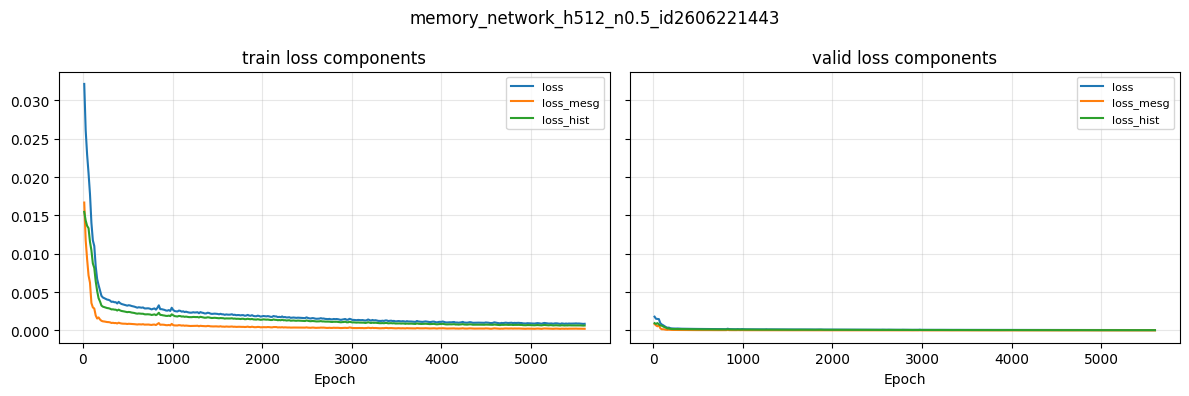

In [27]:
# TensorBoard: total loss vs loss_mesg vs loss_hist (noise = 0.5 run)

example_run = n05_run
tags = ["train/loss", "valid/loss", "train/loss_mesg", "valid/loss_mesg", "train/loss_hist", "valid/loss_hist"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, split in zip(axes, ["train", "valid"]):
    for tag in tags:
        if not tag.startswith(split):
            continue
        df = load_tb_scalars(example_run, tag)
        if df.empty:
            continue
        label = tag.split("/", 1)[1]
        ax.plot(df["epoch"], df["value"], label=label)
    ax.set_xlabel("Epoch")
    ax.set_title(f"{split} loss components")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(example_run.name, fontsize=12)
fig.tight_layout()
plt.show()

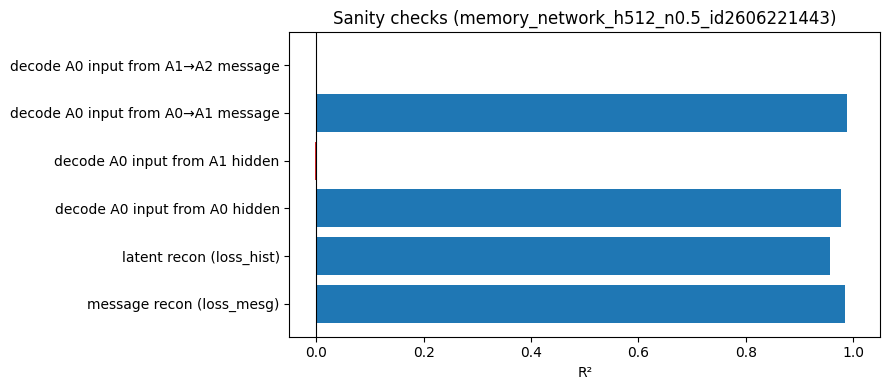

,check,r2,expect
0,message recon (loss_mesg),0.984883,high
1,latent recon (loss_hist),0.956156,high
2,decode A0 input from A0 hidden,0.977210,high
3,decode A0 input from A1 hidden,-0.003016,~0
4,decode A0 input from A0→A1 message,0.988809,high
5,decode A0 input from A1→A2 message,-0.000083,~0


In [28]:
# Training objective + negative controls (noise = 0.5 run)

audit_run = n05_run
audit = audit_training_objectives(audit_run)
lag = audit["lag"]
truth_inp = audit["truth_inp"]
mesgs = audit["mesgs"]
hidden = audit["hidden"]

# Hidden decoding: correct area vs wrong area
r2_a0_from_a0 = ridge_decode_r2(hidden["A0"], truth_inp[..., :1])
r2_a0_from_a1 = ridge_decode_r2(hidden["A1"], truth_inp[..., :1])

# Message decoding: sent pair (A0→A1, ch 2) vs not-sent (A1→A2, ch 4)
mesg_sent = mesgs[:, lag:, 2:3]
mesg_notsent = mesgs[:, lag:, 4:5]
inp_a0 = truth_inp[:, :-lag, :1]
r2_msg_sent = ridge_decode_r2(mesg_sent, inp_a0)
r2_msg_notsent = ridge_decode_r2(mesg_notsent, inp_a0)

controls_df = pd.DataFrame(
    [
        {"check": "message recon (loss_mesg)", "r2": audit["mesg_r2_mean"], "expect": "high"},
        {"check": "latent recon (loss_hist)", "r2": audit["latent_r2_mean"], "expect": "high"},
        {"check": "decode A0 input from A0 hidden", "r2": r2_a0_from_a0, "expect": "high"},
        {"check": "decode A0 input from A1 hidden", "r2": r2_a0_from_a1, "expect": "~0"},
        {"check": "decode A0 input from A0→A1 message", "r2": r2_msg_sent, "expect": "high"},
        {"check": "decode A0 input from A1→A2 message", "r2": r2_msg_notsent, "expect": "~0"},
    ]
)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["C0" if e == "high" else "C3" for e in controls_df["expect"]]
ax.barh(controls_df["check"], controls_df["r2"], color=colors)
ax.set_xlabel("R²")
ax.set_xlim(-0.05, 1.05)
ax.set_title(f"Sanity checks ({audit_run.name})")
ax.axvline(0, color="k", linewidth=0.8)
fig.tight_layout()
plt.show()

controls_df

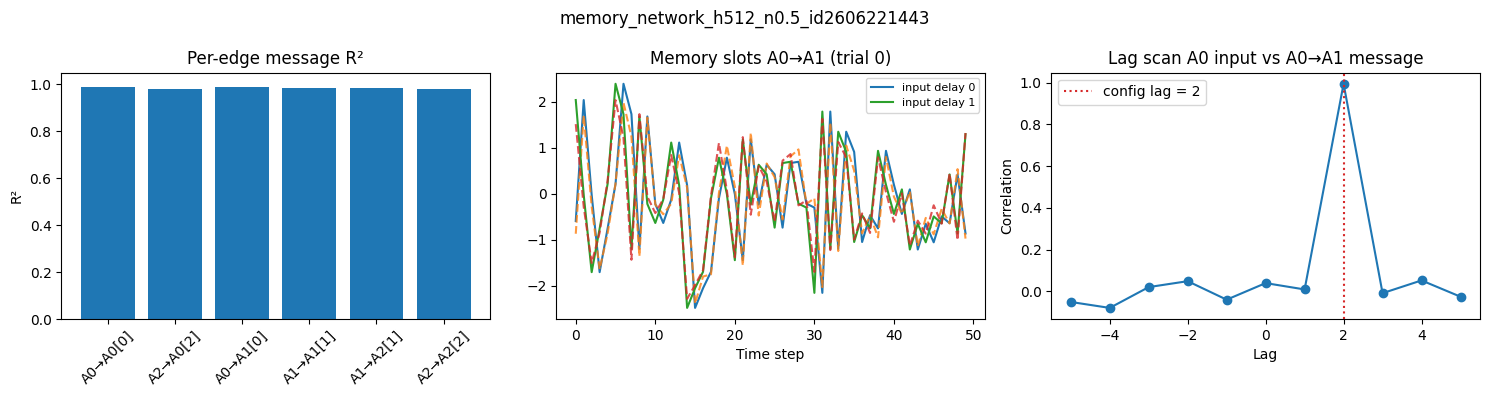

In [31]:
# Per-edge message R² + memory slots + lag scan (noise = 0.5 run)

trial_idx = 0
audit = audit_training_objectives(n05_run)
lag = audit["lag"]
memory = audit["memory"]
truth_inp = audit["truth_inp"]
mesgs = audit["mesgs"]
latents = audit["latents"]
connectome = audit["connectome"]
ranks = audit["ranks"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Per-edge message reconstruction
ax = axes[0]
ax.bar(audit["mesg_labels"], audit["mesg_r2_channels"], color="C0")
ax.set_ylabel("R²")
ax.set_title("Per-edge message R²")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 1.05)

# Memory slots for A0→A1 (message channel 2)
ax = axes[1]
inp_a0 = truth_inp[trial_idx, :, 0]
lat_ch = 4  # first memory slot for A0→A1 with ranks=[1,1,1]
for ti in range(memory):
    stop = None if memory - ti == 0 else -(memory - ti)
    target = inp_a0[ti:stop]
    pred = latents[trial_idx, memory + lag * 2 :, lat_ch + ti][: len(target)]
    ax.plot(target[:50], linestyle="-", label=f"input delay {ti}")
    ax.plot(pred[:50], linestyle="--", alpha=0.8)
ax.set_title(f"Memory slots A0→A1 (trial {trial_idx})")
ax.set_xlabel("Time step")
ax.legend(fontsize=8)

# Lag scan for A0→A1 message vs A0 input
ax = axes[2]
inp = truth_inp[trial_idx, :, 0]
msg = mesgs[trial_idx, :, 2]
scan_lags = np.arange(-5, 6)
scan_corr = []
for shift in scan_lags:
    if shift == 0:
        c = np.corrcoef(inp, msg)[0, 1]
    elif shift > 0:
        c = np.corrcoef(inp[:-shift], msg[shift:])[0, 1]
    else:
        c = np.corrcoef(inp[-shift:], msg[:shift])[0, 1]
    scan_corr.append(c)
ax.plot(scan_lags, scan_corr, marker="o")
ax.axvline(lag, color="C3", linestyle=":", label=f"config lag = {lag}")
ax.set_xlabel("Lag")
ax.set_ylabel("Correlation")
ax.set_title("Lag scan A0 input vs A0→A1 message")
ax.legend()

fig.suptitle(n05_run.name, fontsize=12)
fig.tight_layout()
plt.show()

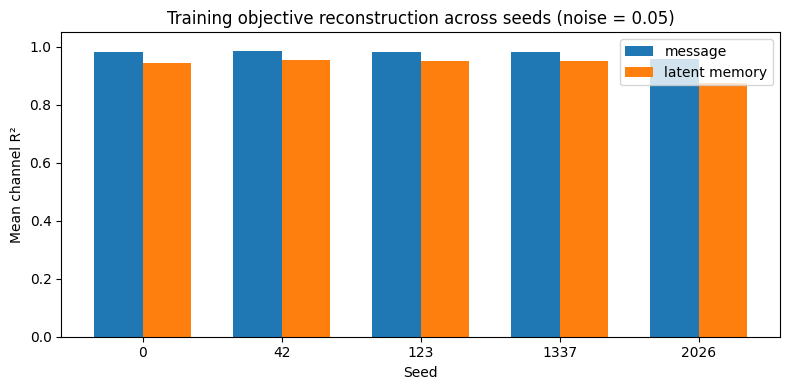

,seed,mesg_r2_mean,latent_r2_mean
0,0,0.982036,0.945668
1,42,0.984883,0.956156
2,123,0.981668,0.951588
3,1337,0.983415,0.952756
4,2026,0.959208,0.875131


In [ ]:
# Seed stability: training objectives should be similar across seeds

seed_runs_dir = Path("..") / "runs" / "seed_runs"
seed_run_dirs = sorted(
    [p for p in seed_runs_dir.iterdir() if p.is_dir()],
    key=lambda p: int(re.search(r"_s(\d+)_", p.name).group(1)),
)

seed_rows = []
for run_dir in seed_run_dirs:
    row = audit_training_objectives(run_dir)
    seed = int(re.search(r"_s(\d+)_", run_dir.name).group(1))
    seed_rows.append(
        {
            "seed": seed,
            "mesg_r2_mean": row["mesg_r2_mean"],
            "latent_r2_mean": row["latent_r2_mean"],
        }
    )

seed_df = pd.DataFrame(seed_rows)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(seed_df))
width = 0.35
ax.bar(x - width / 2, seed_df["mesg_r2_mean"], width, label="message")
ax.bar(x + width / 2, seed_df["latent_r2_mean"], width, label="latent memory")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in seed_df["seed"]])
ax.set_xlabel("Seed")
ax.set_ylabel("Mean channel R²")
ax.set_title("Training objective reconstruction across seeds (noise = 0.05)")
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
plt.show()

seed_df